In [1]:
import os
import shutil
from google.colab import drive

# 1. CÀI ĐẶT THƯ VIỆN CẦN THIẾT
!pip install editdistance
!apt-get install unrar > /dev/null

# 2. MOUNT DRIVE (Để lưu model)
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import shutil
from google.colab import drive

# 1. CÀI ĐẶT THƯ VIỆN CẦN THIẾT
!pip install editdistance
!apt-get install unrar > /dev/null

# 2. MOUNT DRIVE (Để lưu model)
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

CKPT_SAVE_PATH = "/content/drive/MyDrive/ocr_transformer_best.pth"
print(f"--> Checkpoint sẽ được lưu tại: {CKPT_SAVE_PATH}")

# 3. GIẢI NÉN DỮ LIỆU (Train/Valid/Test)
# Cấu hình tên file đã upload
rar_files = {
    "train": "train.rar",
    "valid": "valid.rar",
    "test":  "test.rar"
}

for mode, filename in rar_files.items():
    rar_path = f"/content/{filename}"
    extract_to = f"/content/{mode}" # VD: /content/train

    if os.path.exists(rar_path):
        if not os.path.exists(extract_to):
            os.makedirs(extract_to)
        print(f"Đang giải nén {filename} vào {extract_to}...")

        # Lệnh giải nén (x: extract, -inul: im lặng, -o+: ghi đè)
        # Thêm dấu "" quanh đường dẫn để tránh lỗi nếu tên file có khoảng trắng
        !unrar x -inul -o+ "{rar_path}" "{extract_to}"

        # --- ĐOẠN CODE ĐẾM FILE ---
        total_files = 0
        for root, dirs, files in os.walk(extract_to):
            total_files += len(files)
        # --------------------------

        print(f"--> Xong {mode}! Tổng số file đã giải nén: {total_files}")
    else:
        print(f"[Cảnh báo] Không tìm thấy file {filename}. Hãy upload lên Colab!")

Mounted at /content/drive
--> Checkpoint sẽ được lưu tại: /content/drive/MyDrive/ocr_transformer_best.pth
Đang giải nén train.rar vào /content/train...
--> Xong train! Tổng số file đã giải nén: 330961
Đang giải nén valid.rar vào /content/valid...
--> Xong valid! Tổng số file đã giải nén: 41370
Đang giải nén test.rar vào /content/test...
--> Xong test! Tổng số file đã giải nén: 41370


In [4]:
import pandas as pd

# Tên file CSV gốc bạn upload
csv_files = {
    "train": "written_name_train.csv",
    "valid": "written_name_valid.csv",
    "test":  "written_name_test.csv"
}

# 1. TẠO DATASET TRAIN RÚT GỌN (120k mẫu)
if os.path.exists(csv_files["train"]):
    print("Đang xử lý Train CSV...")
    df = pd.read_csv(csv_files["train"])
    # Lấy 120k mẫu ngẫu nhiên
    SAMPLE_SIZE = 120000
    if len(df) > SAMPLE_SIZE:
        df = df.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)
    df.to_csv("train_mini.csv", index=False)
    print(f"--> Đã tạo 'train_mini.csv' ({len(df)} dòng)")

# 2. TẠO DATASET VALID RÚT GỌN (5k mẫu)
if os.path.exists(csv_files["valid"]):
    print("Đang xử lý Valid CSV...")
    df = pd.read_csv(csv_files["valid"])
    VALID_SIZE = 5000
    if len(df) > VALID_SIZE:
        df = df.sample(n=VALID_SIZE, random_state=42).reset_index(drop=True)
    df.to_csv("valid_mini.csv", index=False)
    print(f"--> Đã tạo 'valid_mini.csv' ({len(df)} dòng)")

# 3. XỬ LÝ DATASET TEST (LỌC RÁC)
if os.path.exists(csv_files["test"]):
    print("Đang xử lý Test CSV...")
    df = pd.read_csv(csv_files["test"])
    # Lọc bỏ UNREADABLE và NaN
    df = df[df['IDENTITY'] != 'UNREADABLE']
    df = df.dropna(subset=['IDENTITY', 'FILENAME'])
    # Sửa tên file: bỏ đường dẫn thừa nếu có (VD: test/img.jpg -> img.jpg)
    df['FILENAME'] = df['FILENAME'].apply(lambda x: os.path.basename(x))

    df.to_csv("test_clean.csv", index=False)
    print(f"--> Đã tạo 'test_clean.csv' ({len(df)} dòng sạch)")

Đang xử lý Train CSV...
--> Đã tạo 'train_mini.csv' (120000 dòng)
Đang xử lý Valid CSV...
--> Đã tạo 'valid_mini.csv' (5000 dòng)
Đang xử lý Test CSV...
--> Đã tạo 'test_clean.csv' (41289 dòng sạch)


In [5]:
import cv2
import numpy as np
import torch
import glob
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm.auto import tqdm

# --- CONFIG ---
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMG_H = 32
IMG_W = 128
BATCH_SIZE = 64
EPOCHS = 30
LR = 1e-4
MAX_LEN = 32
CHARS = "ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789: "
char2idx = {c: i + 3 for i, c in enumerate(CHARS)}
idx2char = {i + 3: c for i, c in enumerate(CHARS)}
PAD = 0; SOS = 1; EOS = 2
NUM_CLASSES = len(CHARS) + 3

# --- HÀM TỰ ĐỘNG TÌM ẢNH (ĐỆ QUY) ---
def find_image_folder(base_path):
    if not os.path.exists(base_path):
        return base_path

    print(f"Đang quét tìm ảnh trong: {base_path} ...")
    for root, dirs, files in os.walk(base_path):
        # Kiểm tra xem folder này có chứa file ảnh jpg/png không
        if any(f.lower().endswith(('.jpg', '.png')) for f in files):
            count = sum(1 for f in files if f.lower().endswith(('.jpg', '.png')))
            if count > 10: # Ngưỡng để tránh folder rác
                print(f"--> TÌM THẤY ẢNH TẠI: {root} (SL: {count})")
                return root
    return base_path

class OCRDataset(Dataset):
    def __init__(self, csv_file, img_dir, mode='train'):
        self.df = pd.read_csv(csv_file)
        self.img_dir = img_dir

        # Transform
        if mode == 'train':
            self.tf = transforms.Compose([
                transforms.ToPILImage(),
                transforms.RandomAffine(degrees=5, translate=(0.05, 0.05), scale=(0.9, 1.1)),
                transforms.ToTensor(),
                transforms.Normalize((0.5,), (0.5,))
            ])
        else:
            self.tf = transforms.Compose([
                transforms.ToPILImage(),
                transforms.ToTensor(),
                transforms.Normalize((0.5,), (0.5,))
            ])

    def encode(self, text):
        text = str(text).upper()
        seq = [SOS]
        for c in text:
            if c in char2idx: seq.append(char2idx[c])
        seq.append(EOS)
        if len(seq) > MAX_LEN: seq = seq[:MAX_LEN]; seq[-1] = EOS
        return torch.tensor(seq, dtype=torch.long)

    # --- HÀM MỚI: CẮT BỎ KHOẢNG TRẮNG THỪA ---
    def crop_to_content(self, img):
        # 1. Đảo ngược màu (Nền trắng -> Đen, Chữ đen -> Trắng) để dễ tìm
        # (Giả sử ảnh đầu vào là nền trắng chữ đen)
        img_inv = 255 - img

        # 2. Tìm các điểm có pixel > 0 (tức là có nét chữ)
        coords = cv2.findNonZero(img_inv)

        if coords is not None:
            # 3. Tìm hình chữ nhật bao quanh (Bounding Rect)
            x, y, w, h = cv2.boundingRect(coords)

            # 4. Cắt (Thêm một chút lề 1-2px để không mất nét)
            crop = img[y:y+h, x:x+w]

            # Nếu cắt xong mà ảnh quá bé (do nhiễu), thì giữ nguyên ảnh gốc
            if crop.shape[0] > 5 and crop.shape[1] > 5:
                return crop

        return img # Trả về ảnh gốc nếu không tìm thấy gì

    def resize_with_padding(self, img, target_h=32, target_w=128):
        h, w = img.shape
        scale = min(target_h / h, target_w / w)
        new_w = int(w * scale); new_h = int(h * scale)
        img_resized = cv2.resize(img, (new_w, new_h))
        padded = np.full((target_h, target_w), 255, dtype=np.uint8)
        padded[:new_h, :new_w] = img_resized
        return padded

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row["FILENAME"])

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None: img = np.zeros((IMG_H, IMG_W), dtype=np.uint8)

        # Binarization (Làm đậm chữ, lọc nhiễu nền)
        try:
            _, img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        except: pass

        # --- ÁP DỤNG CẮT LỀ ---
        img = self.crop_to_content(img)

        img = self.resize_with_padding(img, IMG_H, IMG_W)
        img = self.tf(img)
        label = self.encode(row["IDENTITY"])
        return img, label

    def __len__(self): return len(self.df)

def collate_fn(batch):
    imgs, labels = zip(*batch)
    imgs = torch.stack(imgs)
    max_len = max(len(l) for l in labels)
    padded_labels = torch.full((len(labels), max_len), PAD, dtype=torch.long)
    for i, l in enumerate(labels): padded_labels[i, :len(l)] = l
    return imgs, padded_labels

# --- KHỞI TẠO DATALOADER ---
print("\n--- CHECK ĐƯỜNG DẪN ẢNH ---")
real_train_dir = find_image_folder("/content/train")
real_valid_dir = find_image_folder("/content/valid")

train_ds = OCRDataset("train_mini.csv", real_train_dir, mode='train')
valid_ds = OCRDataset("valid_mini.csv", real_valid_dir, mode='valid')

train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True, collate_fn=collate_fn, num_workers=2, pin_memory=True)
valid_loader = DataLoader(valid_ds, BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=2, pin_memory=True)
print(f"Ready: Train={len(train_ds)}, Valid={len(valid_ds)}")


--- CHECK ĐƯỜNG DẪN ẢNH ---
Đang quét tìm ảnh trong: /content/train ...
--> TÌM THẤY ẢNH TẠI: /content/train/train/train (SL: 330961)
Đang quét tìm ảnh trong: /content/valid ...
--> TÌM THẤY ẢNH TẠI: /content/valid/valid/valid (SL: 41370)
Ready: Train=120000, Valid=5000


In [3]:
from torch import nn

class CNNEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 64, 3, 1, 1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, 1, 1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(128, 256, 3, 1, 1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d((2, 1)),
            nn.Conv2d(256, 512, 3, 1, 1), nn.BatchNorm2d(512), nn.ReLU(), nn.MaxPool2d((2, 1)),
        )
    def forward(self, x):
        x = self.cnn(x)
        b, c, h, w = x.shape
        x = x.permute(0, 3, 1, 2).contiguous()
        x = x.view(b, w, c * h)
        return x

class OCRTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = CNNEncoder()
        self.enc_proj = nn.Linear(1024, 256)
        self.embed = nn.Embedding(NUM_CLASSES, 256)
        self.pos = nn.Parameter(torch.randn(1, MAX_LEN, 256))
        decoder_layer = nn.TransformerDecoderLayer(d_model=256, nhead=4, dropout=0.1, batch_first=True)
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=3)
        self.fc = nn.Linear(256, NUM_CLASSES)
    def forward(self, img, tgt):
        mem = self.encoder(img); mem = self.enc_proj(mem)
        tgt_emb = self.embed(tgt) + self.pos[:, :tgt.size(1)]
        tgt_mask = torch.triu(torch.ones(tgt.size(1), tgt.size(1), device=tgt.device), diagonal=1).bool()
        out = self.decoder(tgt_emb, mem, tgt_mask=tgt_mask)
        return self.fc(out)

Đang tìm ảnh trong /content/train...
✅ Tìm thấy 330961 ảnh. Đang chọn ngẫu nhiên 10 ảnh...


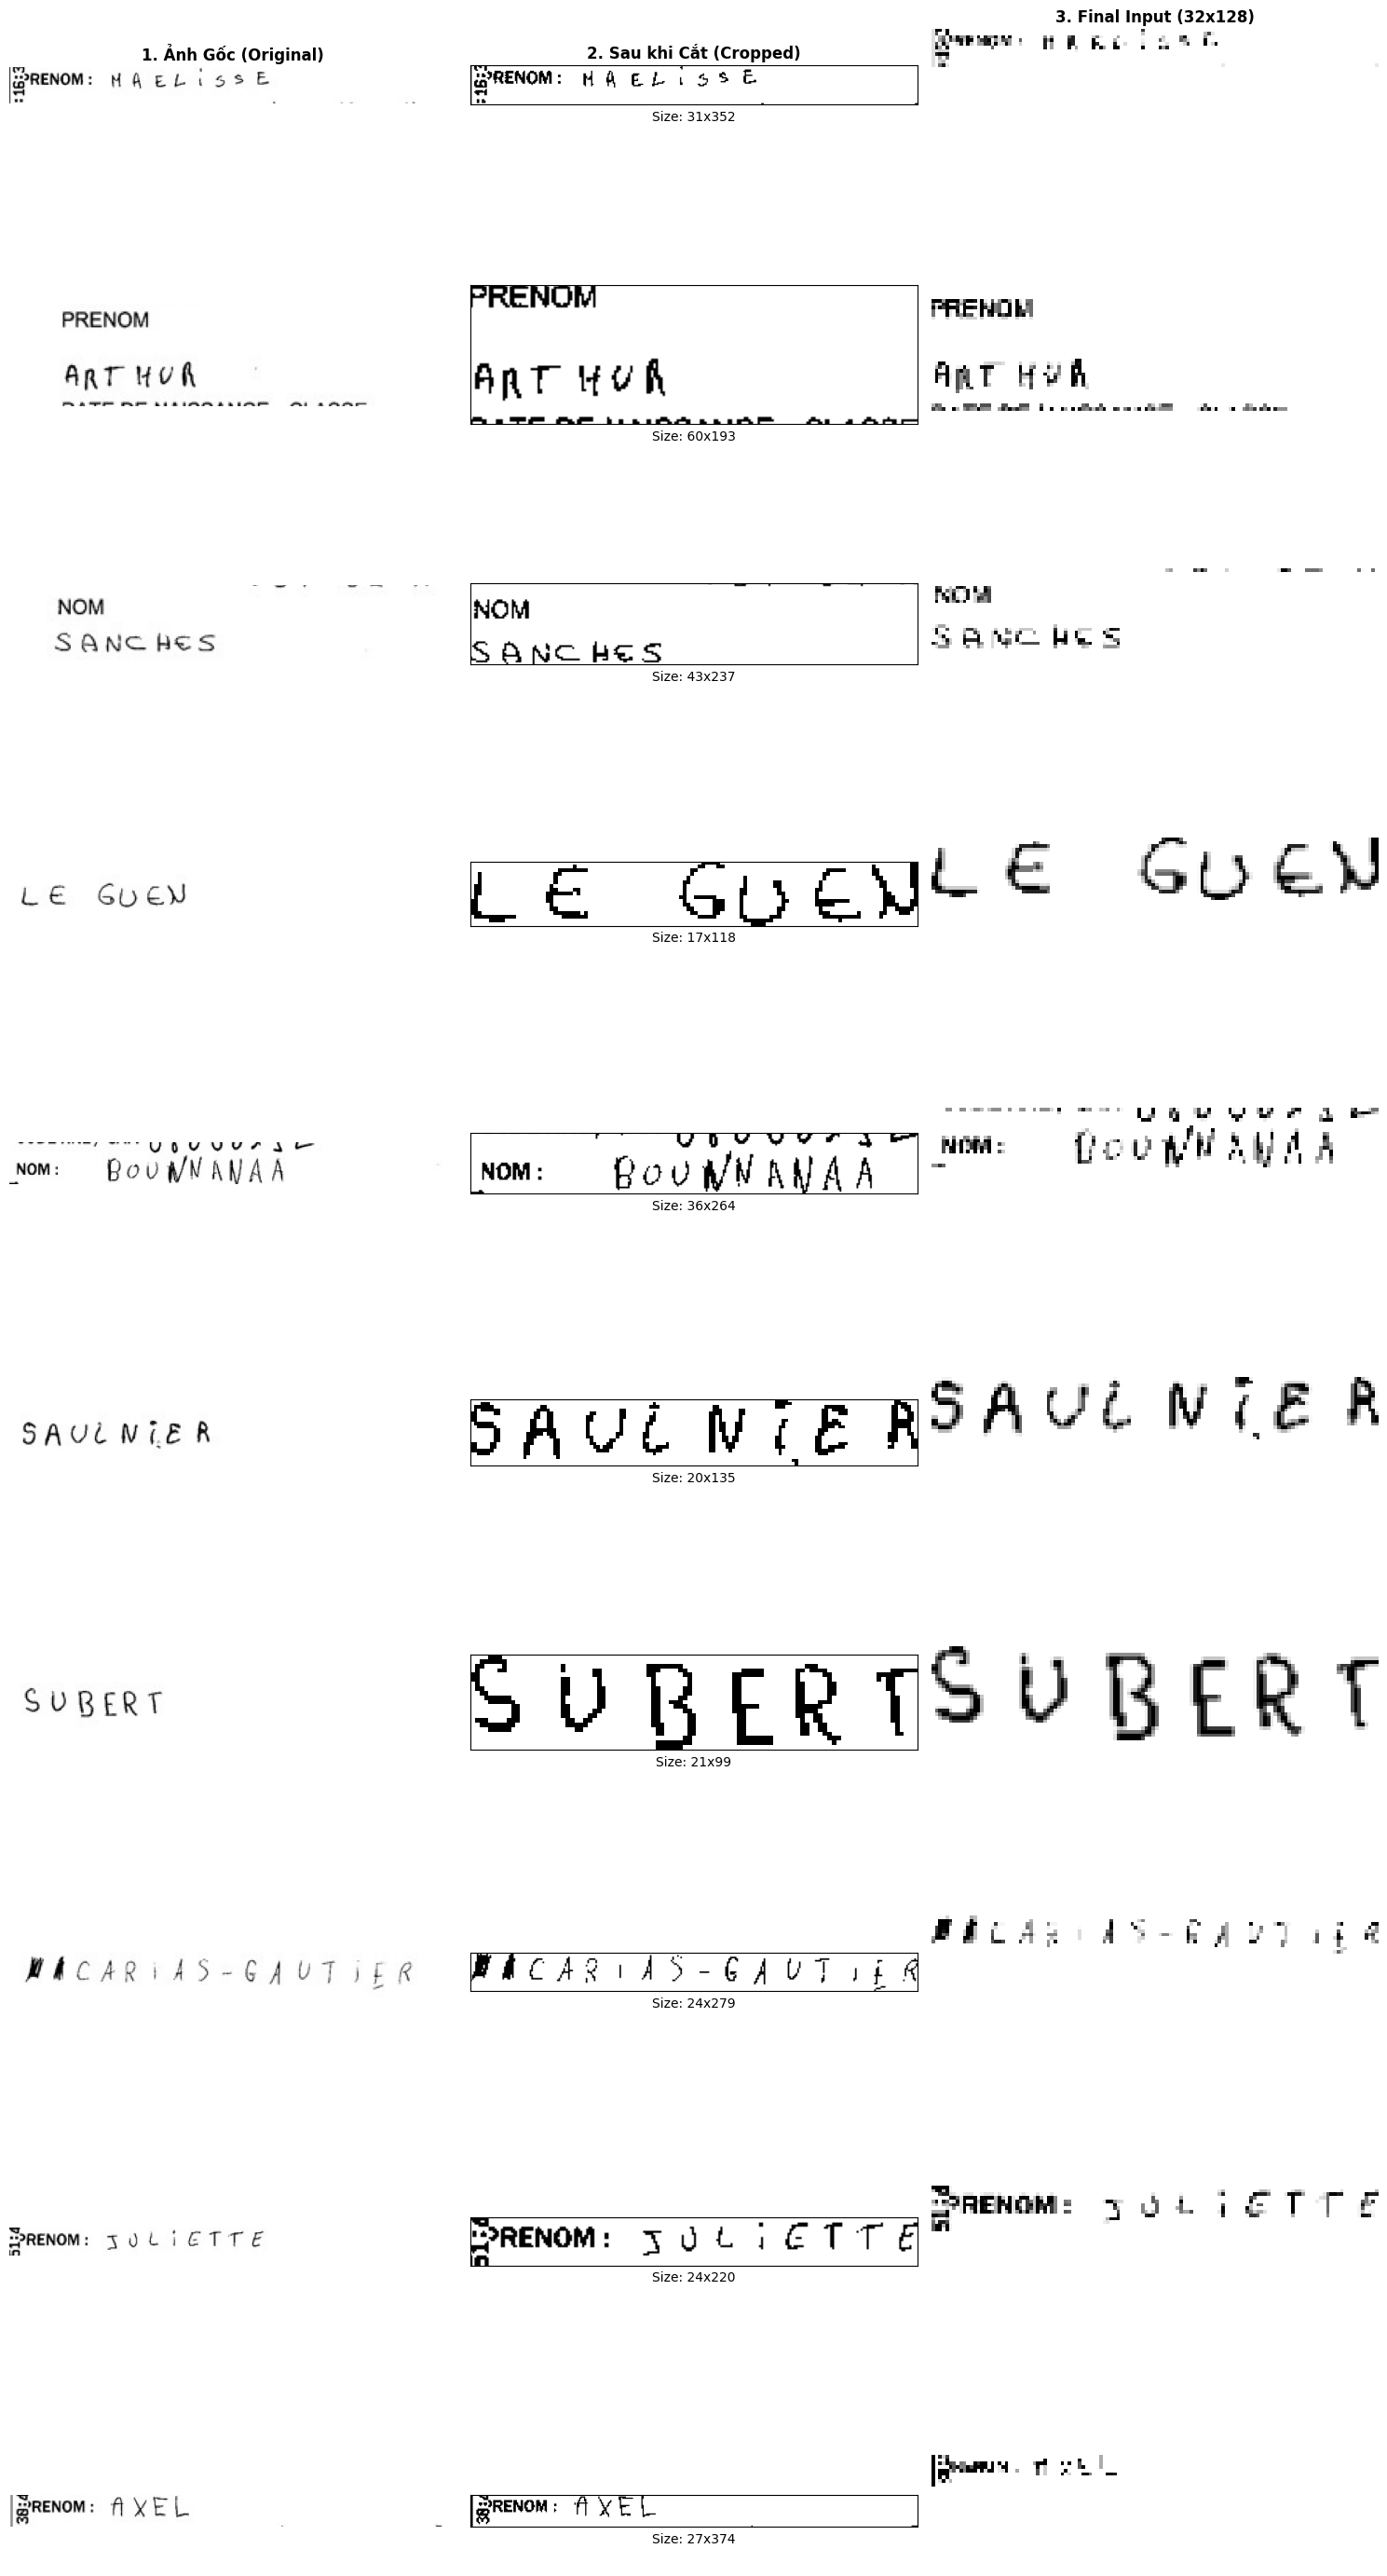

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import random
import glob

# --- CẤU HÌNH ---
IMG_H = 32
IMG_W = 128
# Đường dẫn folder ảnh (Sửa lại nếu bạn để ở chỗ khác)
# Code sẽ tự tìm ảnh trong này và các thư mục con
ROOT_DIR = "/content/train"

# --- CÁC HÀM XỬ LÝ (Copy từ Dataset) ---
def crop_to_content(img):
    """Cắt bỏ phần thừa (khoảng trắng) xung quanh chữ"""
    # 1. Đảo ngược màu (Nền trắng -> Đen) để tìm biên
    img_inv = 255 - img

    # 2. Tìm tất cả điểm ảnh có nét chữ
    coords = cv2.findNonZero(img_inv)

    if coords is not None:
        # 3. Tìm hình chữ nhật bao quanh
        x, y, w, h = cv2.boundingRect(coords)

        # 4. Cắt (thêm lề 1px để không bị sát quá)
        crop = img[y:y+h, x:x+w]

        # Chỉ trả về nếu ảnh sau cắt không quá bé (tránh cắt nhầm nhiễu)
        if crop.shape[0] > 5 and crop.shape[1] > 5:
            return crop

    return img # Trả về gốc nếu không tìm thấy

def resize_with_padding(img, target_h=32, target_w=128):
    """Resize giữ tỷ lệ và thêm viền trắng"""
    h, w = img.shape
    scale = min(target_h / h, target_w / w)
    new_w = int(w * scale)
    new_h = int(h * scale)

    img_resized = cv2.resize(img, (new_w, new_h))

    # Tạo nền trắng
    padded_img = np.full((target_h, target_w), 255, dtype=np.uint8)

    # Dán ảnh vào (lệch trái hoặc giữa tùy chọn, ở đây là lệch trái)
    padded_img[:new_h, :new_w] = img_resized

    return padded_img

# --- CHẠY KIỂM TRA TRÊN 10 ẢNH NGẪU NHIÊN ---
# 1. Tìm tất cả file ảnh
all_images = []
print(f"Đang tìm ảnh trong {ROOT_DIR}...")
for root, dirs, files in os.walk(ROOT_DIR):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            all_images.append(os.path.join(root, file))

if len(all_images) == 0:
    print("❌ Không tìm thấy ảnh nào! Hãy kiểm tra lại đường dẫn ROOT_DIR.")
else:
    print(f"✅ Tìm thấy {len(all_images)} ảnh. Đang chọn ngẫu nhiên 10 ảnh...")

    # Lấy ngẫu nhiên 10 ảnh
    samples = random.sample(all_images, min(10, len(all_images)))

    # Vẽ hình
    fig, axes = plt.subplots(len(samples), 3, figsize=(15, 3 * len(samples)))
    # Tiêu đề cột
    if len(samples) > 1:
        axes[0, 0].set_title("1. Ảnh Gốc (Original)", fontsize=12, fontweight='bold')
        axes[0, 1].set_title("2. Sau khi Cắt (Cropped)", fontsize=12, fontweight='bold')
        axes[0, 2].set_title(f"3. Final Input ({IMG_H}x{IMG_W})", fontsize=12, fontweight='bold')

    for i, img_path in enumerate(samples):
        # Đọc ảnh
        img_orig = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        # Binarize (Mô phỏng bước làm đậm chữ)
        _, img_bin = cv2.threshold(img_orig, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        # Bước 1: Cắt
        img_crop = crop_to_content(img_bin)

        # Bước 2: Resize & Pad
        img_final = resize_with_padding(img_crop, IMG_H, IMG_W)

        # Hiển thị
        ax = axes[i] if len(samples) > 1 else axes

        # Cột 1: Gốc
        ax[0].imshow(img_orig, cmap='gray')
        ax[0].axis('off')

        # Cột 2: Cropped (Vẽ khung đỏ bao quanh để dễ nhìn kích thước thật)
        ax[1].imshow(img_crop, cmap='gray')
        h_c, w_c = img_crop.shape
        ax[1].set_xlabel(f"Size: {h_c}x{w_c}")
        # Bỏ trục toạ độ nhưng giữ nhãn
        ax[1].set_xticks([]); ax[1].set_yticks([])

        # Cột 3: Final
        ax[2].imshow(img_final, cmap='gray')
        ax[2].axis('off')

    plt.tight_layout()
    plt.show()

In [8]:
model = OCRTransformer().to(DEVICE)
criterion = nn.CrossEntropyLoss(ignore_index=PAD)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
# Bỏ verbose=True để tránh lỗi TypeError
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

best_val_loss = 1e9

if os.path.exists(CKPT_SAVE_PATH):
    print(f"Load checkpoint: {CKPT_SAVE_PATH}")
    ckpt = torch.load(CKPT_SAVE_PATH, map_location=DEVICE)
    model.load_state_dict(ckpt['model'])
    best_val_loss = ckpt.get('best_loss', 1e9)
    print(f"--> Best Val Loss cũ: {best_val_loss:.4f}")

print(">>> START TRAINING...")
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for imgs, labels in pbar:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out = model(imgs, labels[:, :-1])
        loss = criterion(out.reshape(-1, NUM_CLASSES), labels[:, 1:].reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item(); pbar.set_postfix({'loss': loss.item()})

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for imgs, labels in valid_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            out = model(imgs, labels[:, :-1])
            loss = criterion(out.reshape(-1, NUM_CLASSES), labels[:, 1:].reshape(-1))
            val_loss += loss.item()

    avg_train = train_loss/len(train_loader); avg_val = val_loss/len(valid_loader)
    curr_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1} | Train: {avg_train:.4f} | Val: {avg_val:.4f} | LR: {curr_lr:.1e}")

    scheduler.step(avg_val)
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save({'model': model.state_dict(), 'best_loss': best_val_loss, 'config': {'CHARS': CHARS}}, CKPT_SAVE_PATH)
        print("--> Saved Best Model!")

>>> START TRAINING...


Epoch 1/50:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 1 | Train: 1.5150 | Val: 0.8980 | LR: 1.0e-04
--> Saved Best Model!


Epoch 2/50:   0%|          | 0/1875 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7df815b774c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^Exception ignored in: ^^<function _MultiProcessingDataLoaderIter.__del__ at 0x7df815b774c0>^
Traceback (most recent call last):

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
        self._shutdown_workers()assert self._parent_pid == os.getpid(), 'can only test a child process'

   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive(): 
                ^^^^^^^^^^^^^^^^^^^^^^^
^

...

Epoch 33/50:   0%|          | 0/1875 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7df815b774c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()Exception ignored in: 
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
<function _MultiProcessingDataLoaderIter.__del__ at 0x7df815b774c0>
    Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
if w.is_alive():
     self._shutdown_workers() 
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
       if w.is_alive(): 
^ ^ ^ ^ ^ ^ ^ ^^^^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    ^assert self._parent_pid == os.getpid(), 'can only test a child process'^
^ ^  ^ ^  
   File "/usr/lib

Epoch 33 | Train: 0.2371 | Val: 0.2486 | LR: 1.0e-04
--> Saved Best Model!


Epoch 34/50:   0%|          | 0/1875 [00:00<?, ?it/s]

KeyboardInterrupt: 

Đang quét tìm ảnh trong: /content/test ...
--> TÌM THẤY ẢNH TẠI: /content/test/test/test (SL: 41370)
Testing on 41289 samples...
>>> RUNNING EVALUATION...


  0%|          | 0/646 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7df815b774c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()Exception ignored in: 
<function _MultiProcessingDataLoaderIter.__del__ at 0x7df815b774c0>  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers

    Traceback (most recent call last):
if w.is_alive():  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__

     self._shutdown_workers() 
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
       if w.is_alive(): 
^ ^ ^ ^ ^ ^ ^ ^^^^^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    ^assert self._parent_pid == os.getpid(), 'can only test a child process'
^ ^ ^  ^ 
   File "/usr/lib/


ACCURACY: 71.96%
CER: 0.1038


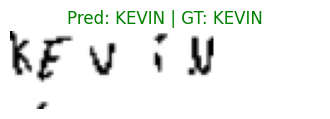

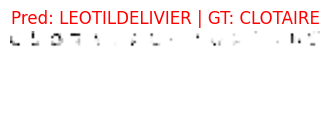

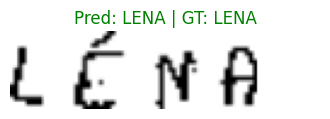

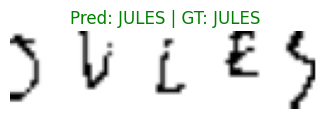

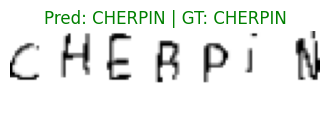

In [9]:
import editdistance
import matplotlib.pyplot as plt

# Load Best Model
if os.path.exists(CKPT_SAVE_PATH):
    ckpt = torch.load(CKPT_SAVE_PATH, map_location=DEVICE)
    model.load_state_dict(ckpt['model'])
model.eval()

# Tìm đường dẫn ảnh Test
real_test_dir = find_image_folder("/content/test")
if os.path.exists("test_clean.csv") and os.path.exists(real_test_dir):
    test_ds = OCRDataset("test_clean.csv", real_test_dir, mode='test')
    test_loader = DataLoader(test_ds, BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=2)
    print(f"Testing on {len(test_ds)} samples...")
else:
    print("[LỖI] Không tìm thấy CSV test hoặc Folder ảnh Test!")

def decode(indices):
    res = []
    for idx in indices:
        idx = idx.item()
        if idx == EOS: break
        if idx >= 3: res.append(idx2char[idx])
    return "".join(res)

@torch.no_grad()
def predict_batch(imgs):
    B = imgs.size(0); imgs = imgs.to(DEVICE)
    tgt = torch.full((B, 1), SOS, dtype=torch.long, device=DEVICE)
    for _ in range(MAX_LEN):
        out = model(imgs, tgt)
        next_token = out[:, -1].argmax(-1, keepdim=True)
        tgt = torch.cat([tgt, next_token], dim=1)
    return tgt[:, 1:]

# Đánh giá
correct = 0; total = 0; total_cer = 0; total_chars = 0
viz_samples = []
def compute_cer(pred, gt):
    if len(gt) == 0:
        return 0
    return editdistance.eval(pred, gt) / len(gt)
print(">>> RUNNING EVALUATION...")
with torch.no_grad():
    for imgs, labels in tqdm(test_loader):
        preds = predict_batch(imgs)
        for i in range(len(imgs)):
            pred_txt = decode(preds[i]).replace("PRENOM:", "").replace("NOM:", "").strip()
            gt_txt = decode(labels[i]).replace("PRENOM:", "").replace("NOM:", "").strip()

            if pred_txt == gt_txt: correct += 1
            if len(gt_txt) > 0:
                total_cer += compute_cer(pred_txt, gt_txt)
            total += 1
            if len(viz_samples) < 5: viz_samples.append((imgs[i], pred_txt, gt_txt))

print(f"\nACCURACY: {correct/total:.2%}")
print(f"CER: {total_cer/total:.4f}")

# Show ảnh
for img, pred, gt in viz_samples:
    img_np = img.permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5
    plt.figure(figsize=(4, 1.5))
    plt.imshow(img_np.squeeze(), cmap='gray', vmin=0, vmax=1)
    plt.title(f"Pred: {pred} | GT: {gt}", color='green' if pred==gt else 'red')
    plt.axis('off'); plt.show()